# PhysiCell Diffusion Uptake Sweep

This notebook runs a parameter sweep for the PhysiCell diffusion-with-cells-uptake unit test using the attached XML template.

For each case it varies:
- voxel size `dx`
- cell `uptake_rate`
- `dt_diffusion`
- cell total volume, with nuclear volume fixed to 10% of total

Each run is written to its own results folder named by the swept parameters. The notebook then exports PhysiCell-only concentration traces, compares them to the analytical uptake reference using the same center/average workflow as `uptake_tools_comparison.ipynb`, and plots both concentrations and errors.


In [20]:
from pathlib import Path
import os
import shutil
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pctk import multicellds

ROOT = Path('/home/tntiniak/Work/observatory_benchmark')
CODE_DIR = ROOT / 'PhysiCell' / 'code'
CONFIG_DIR = CODE_DIR / 'config'
TEMPLATE_XML = CODE_DIR / 'config' / '__tmp_uptake_tune.xml'
WORKING_XML = CODE_DIR / 'config' / '__generated_uptake_sweep_case.xml'
SWEEP_CELL_POSITIONS_CSV = CONFIG_DIR / 'cells_10_sweep.csv'
SWEEP_SINKS_CSV = CONFIG_DIR / 'cells_10.csv'
SWEEP_ROOT = ROOT / 'PhysiCell' / 'results' / 'diffusion_uptake_sweep'
ANALYTICAL_CSV = ROOT / 'analytical_solutions' / 'diffusion' / 'Cellsatcenter' / 'analytical_values.csv'
OUTPUT_FILENAME = 'physicell_uptake_plot_data.csv'

VOXEL_SIZES_UM = [ 2,3,5.0, 10.0, 20.0, 40.0]
UPTAKE_RATES_PER_MIN = [12044]
DT_DIFFUSION_MIN = [0.005, 0.01, 0.1]
TOTAL_VOLUMES_UM3 = [1.0, 523.0, 1000.0]

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 8,
})

SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
TEMPLATE_XML, SWEEP_ROOT


(PosixPath('/home/tntiniak/Work/observatory_benchmark/PhysiCell/code/config/__tmp_uptake_tune.xml'),
 PosixPath('/home/tntiniak/Work/observatory_benchmark/PhysiCell/results/diffusion_uptake_sweep'))

In [21]:
def format_token(value: float) -> str:
    formatted = f'{value:g}'
    return formatted.replace('-', 'm').replace('.', 'p').replace('+', '')


def build_run_id(dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> str:
    return (
        f'dx_{format_token(dx_um)}um__'
        f'uptake_{format_token(uptake_rate)}__'
        f'dtdiff_{format_token(dt_diffusion)}min__'
        f'volume_{format_token(total_volume_um3)}um3'
    )


def nearest_axis_index(axis_values: np.ndarray, coordinate: float) -> int:
    return int(np.abs(axis_values - coordinate).argmin())


def voxel_axes_for_domain(dx_um: float, minimum_um: float = -120.0, maximum_um: float = 120.0) -> np.ndarray:
    voxel_count = int(round((maximum_um - minimum_um) / dx_um))
    return minimum_um + (np.arange(voxel_count, dtype=float) + 0.5) * dx_um


def generate_center_voxel_positions(dx_um: float) -> np.ndarray:
    axis = voxel_axes_for_domain(dx_um)
    center_z = float(axis[nearest_axis_index(axis, 0.0)])

    xy_candidates = []
    for x_um in axis:
        for y_um in axis:
            xy_candidates.append((float(x_um), float(y_um), float(x_um**2 + y_um**2)))

    xy_candidates.sort(key=lambda values: (values[2], abs(values[0]), abs(values[1]), values[0], values[1]))
    selected_xy = [(x_um, y_um) for x_um, y_um, _ in xy_candidates[:12]]
    selected_xy.sort(key=lambda values: (abs(values[0]) + abs(values[1]), values[0], values[1]))

    return np.array([[x_um, y_um, center_z, 0.0] for x_um, y_um in selected_xy], dtype=float)


def write_center_voxel_csvs(dx_um: float) -> np.ndarray:
    positions = generate_center_voxel_positions(dx_um)
    np.savetxt(SWEEP_CELL_POSITIONS_CSV, positions, delimiter=',', fmt='%.10g')
    np.savetxt(SWEEP_SINKS_CSV, positions, delimiter=',', fmt='%.10g')
    return positions


def configure_case_xml(
    template_xml: Path,
    output_xml: Path,
    output_dir: Path,
    dx_um: float,
    uptake_rate: float,
    dt_diffusion: float,
    total_volume_um3: float,
) -> None:
    tree = ET.parse(template_xml)
    root = tree.getroot()

    for axis in ['dx', 'dy', 'dz']:
        node = root.find(f'.//domain/{axis}')
        if node is None:
            raise KeyError(f'Missing domain/{axis} in {template_xml}')
        node.text = str(dx_um)

    dt_node = root.find('.//overall/dt_diffusion')
    if dt_node is None:
        raise KeyError(f'Missing overall/dt_diffusion in {template_xml}')
    dt_node.text = str(dt_diffusion)

    uptake_node = root.find('.//cell_definitions//secretion//substrate/uptake_rate')
    if uptake_node is None:
        raise KeyError(f'Missing uptake_rate in {template_xml}')
    uptake_node.text = str(uptake_rate)

    total_volume_node = root.find('.//cell_definitions//volume/total')
    if total_volume_node is None:
        raise KeyError(f'Missing volume/total in {template_xml}')
    total_volume_node.text = str(total_volume_um3)

    nuclear_volume_node = root.find('.//cell_definitions//volume/nuclear')
    if nuclear_volume_node is None:
        raise KeyError(f'Missing volume/nuclear in {template_xml}')
    nuclear_volume_node.text = str(0.1 * total_volume_um3)

    save_folder_node = root.find('.//save/folder')
    if save_folder_node is None:
        raise KeyError(f'Missing save/folder in {template_xml}')
    save_folder_node.text = os.path.relpath(output_dir, CODE_DIR)

    tree.write(output_xml, encoding='utf-8', xml_declaration=False)


def run_physicell_case(case_xml: Path, verbose: bool = False) -> str:
    try:
        completed = subprocess.run(
            ['./project', str(case_xml)],
            cwd=CODE_DIR,
            check=True,
            capture_output=True,
            text=True,
        )
    except subprocess.CalledProcessError as exc:
        message = (
            f'PhysiCell run failed for {case_xml}\n'
            f'Exit code: {exc.returncode}\n'
            f'STDOUT tail:\n{exc.stdout[-4000:]}\n'
            f'STDERR tail:\n{exc.stderr[-4000:]}'
        )
        raise RuntimeError(message) from exc
    if verbose:
        print(completed.stdout[-2000:])
    return completed.stdout


def load_physicell_run(folder: Path, settings_xml: Path, run_id: str, dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> pd.DataFrame:
    settings_root = ET.parse(settings_xml).getroot()
    cell_positions_filename = settings_root.findtext('.//initial_conditions/cell_positions/filename')
    if cell_positions_filename is None:
        raise ValueError(f'No cell positions filename found in {settings_xml}')

    cell_positions_path = settings_xml.parent / cell_positions_filename
    cell_positions = np.loadtxt(cell_positions_path, delimiter=',', usecols=(0, 1, 2), ndmin=2)

    output_xml_paths = sorted(folder.glob('output*.xml'))
    if not output_xml_paths:
        raise FileNotFoundError(f'No output XML files found in {folder}')

    output_times = []
    for xml_path in output_xml_paths:
        root = ET.parse(xml_path).getroot()
        output_times.append(float(root.findtext('.//current_time')))

    reader = multicellds.MultiCellDS(output_folder=str(folder))

    average_uM = []
    center_uM = []
    cell_voxel_average_uM = []
    center_index = None
    cell_voxel_indices = None

    for _, microenvironment in reader.microenvironment_as_matrix_iterator():
        concentration_field = microenvironment[4]

        if center_index is None:
            x_axis = np.unique(microenvironment[0])
            y_axis = np.unique(microenvironment[1])
            z_axis = np.unique(microenvironment[2])
            dims = (len(x_axis), len(y_axis), len(z_axis))

            center_index = np.ravel_multi_index(
                (
                    nearest_axis_index(x_axis, 0.0),
                    nearest_axis_index(y_axis, 0.0),
                    nearest_axis_index(z_axis, 0.0),
                ),
                dims,
            )

            cell_voxel_indices = []
            for x_cell, y_cell, z_cell in cell_positions:
                voxel_index = np.ravel_multi_index(
                    (
                        nearest_axis_index(x_axis, x_cell),
                        nearest_axis_index(y_axis, y_cell),
                        nearest_axis_index(z_axis, z_cell),
                    ),
                    dims,
                )
                cell_voxel_indices.append(voxel_index)
            cell_voxel_indices = np.unique(cell_voxel_indices)

        average_uM.append(concentration_field.mean() / 602.2)
        center_uM.append(concentration_field[center_index] / 602.2)
        cell_voxel_average_uM.append(concentration_field[cell_voxel_indices].mean() / 602.2)

    if len(output_times) != len(average_uM):
        raise ValueError(
            f'Time count mismatch for {run_id}: {len(output_times)} output XML files versus {len(average_uM)} microenvironment snapshots'
        )

    return pd.DataFrame({
        'tool': 'PhysiCell',
        'run_id': run_id,
        'dx_um': dx_um,
        'uptake_rate_per_min': uptake_rate,
        'dt_diffusion_min': dt_diffusion,
        'total_volume_um3': total_volume_um3,
        'nuclear_volume_um3': 0.1 * total_volume_um3,
        'average_source': 'mean over all voxels',
        'center_source': 'mean over unique voxels nearest the configured cell positions',
        'raw_center_source': 'single center voxel nearest the origin',
        'time_min': np.round(np.array(output_times, dtype=float), 4),
        'average_uM': np.array(average_uM, dtype=float),
        'center_uM': np.array(cell_voxel_average_uM, dtype=float),
        'raw_center_uM': np.array(center_uM, dtype=float),
    })


def style_axis(axis) -> None:
    axis.grid(True, alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


## Run The Sweep

This cell rewrites a temporary case XML for each parameter combination, launches PhysiCell with that XML, exports a `physicell_uptake_plot_data.csv` into the run folder, and collects all runs into one table. The volume sweep uses paired values only: `total` is taken from `TOTAL_VOLUMES_UM3`, and `nuclear` is set to 10% of the same value.


In [22]:
summary_rows = []
all_runs = []
run_directories = []

for dx_um in VOXEL_SIZES_UM:
    for uptake_rate in UPTAKE_RATES_PER_MIN:
        for dt_diffusion in DT_DIFFUSION_MIN:
            for total_volume_um3 in TOTAL_VOLUMES_UM3:
                run_id = build_run_id(dx_um, uptake_rate, dt_diffusion, total_volume_um3)
                output_dir = SWEEP_ROOT / run_id

                if output_dir.exists():
                    shutil.rmtree(output_dir)
                output_dir.mkdir(parents=True, exist_ok=True)

                print(f'Running {run_id}')
                generated_positions = write_center_voxel_csvs(dx_um)
                configure_case_xml(
                    template_xml=TEMPLATE_XML,
                    output_xml=WORKING_XML,
                    output_dir=output_dir,
                    dx_um=dx_um,
                    uptake_rate=uptake_rate,
                    dt_diffusion=dt_diffusion,
                    total_volume_um3=total_volume_um3,
                )
                run_physicell_case(WORKING_XML)

                run_frame = load_physicell_run(
                    folder=output_dir,
                    settings_xml=WORKING_XML,
                    run_id=run_id,
                    dx_um=dx_um,
                    uptake_rate=uptake_rate,
                    dt_diffusion=dt_diffusion,
                    total_volume_um3=total_volume_um3,
                )
                run_frame.to_csv(output_dir / OUTPUT_FILENAME, index=False)

                all_runs.append(run_frame)
                run_directories.append(output_dir)
                summary_rows.append({
                    'run_id': run_id,
                    'output_dir': str(output_dir),
                    'dx_um': dx_um,
                    'uptake_rate_per_min': uptake_rate,
                    'dt_diffusion_min': dt_diffusion,
                    'total_volume_um3': total_volume_um3,
                    'nuclear_volume_um3': 0.1 * total_volume_um3,
                    'cell_count': len(generated_positions),
                    'n_timepoints': len(run_frame),
                    'final_average_uM': float(run_frame['average_uM'].iloc[-1]),
                    'final_center_uM': float(run_frame['center_uM'].iloc[-1]),
                })

all_runs = pd.concat(all_runs, ignore_index=True)
run_summary = pd.DataFrame(summary_rows).sort_values(['dx_um', 'uptake_rate_per_min', 'dt_diffusion_min', 'total_volume_um3']).reset_index(drop=True)
run_summary.to_csv(SWEEP_ROOT / 'run_summary.csv', index=False)
run_summary


Running dx_2um__uptake_12044__dtdiff_0p005min__volume_1um3
Running dx_2um__uptake_12044__dtdiff_0p005min__volume_523um3
Running dx_2um__uptake_12044__dtdiff_0p005min__volume_1000um3
Running dx_2um__uptake_12044__dtdiff_0p01min__volume_1um3
Running dx_2um__uptake_12044__dtdiff_0p01min__volume_523um3
Running dx_2um__uptake_12044__dtdiff_0p01min__volume_1000um3
Running dx_2um__uptake_12044__dtdiff_0p1min__volume_1um3
Running dx_2um__uptake_12044__dtdiff_0p1min__volume_523um3
Running dx_2um__uptake_12044__dtdiff_0p1min__volume_1000um3
Running dx_3um__uptake_12044__dtdiff_0p005min__volume_1um3
Running dx_3um__uptake_12044__dtdiff_0p005min__volume_523um3
Running dx_3um__uptake_12044__dtdiff_0p005min__volume_1000um3
Running dx_3um__uptake_12044__dtdiff_0p01min__volume_1um3
Running dx_3um__uptake_12044__dtdiff_0p01min__volume_523um3
Running dx_3um__uptake_12044__dtdiff_0p01min__volume_1000um3
Running dx_3um__uptake_12044__dtdiff_0p1min__volume_1um3
Running dx_3um__uptake_12044__dtdiff_0p1min__

,run_id,output_dir,dx_um,uptake_rate_per_min,dt_diffusion_min,total_volume_um3,nuclear_volume_um3,cell_count,n_timepoints,final_average_uM,final_center_uM
0,dx_2um__uptake_12044__dtdiff_0p005min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.005,1.0,0.1,12,101,9.982542,6.133914
1,dx_2um__uptake_12044__dtdiff_0p005min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.005,523.0,52.3,12,101,9.978191,9.398635
2,dx_2um__uptake_12044__dtdiff_0p005min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.005,1000.0,100.0,12,101,9.978098,9.434450
3,dx_2um__uptake_12044__dtdiff_0p01min__volume_1um3,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.010,1.0,0.1,12,101,9.989013,6.400801
4,dx_2um__uptake_12044__dtdiff_0p01min__volume_5...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.010,523.0,52.3,12,101,9.987738,9.686736
5,dx_2um__uptake_12044__dtdiff_0p01min__volume_1...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.010,1000.0,100.0,12,101,9.987722,9.705894
6,dx_2um__uptake_12044__dtdiff_0p1min__volume_1um3,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.100,1.0,0.1,12,101,9.997443,6.660351
7,dx_2um__uptake_12044__dtdiff_0p1min__volume_52...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.100,523.0,52.3,12,101,9.997428,9.972879
8,dx_2um__uptake_12044__dtdiff_0p1min__volume_10...,/home/tntiniak/Work/observatory_benchmark/Phys...,2.0,12044,0.100,1000.0,100.0,12,101,9.997430,9.974086
9,dx_3um__uptake_12044__dtdiff_0p005min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,3.0,12044,0.005,1.0,0.1,12,101,9.961922,6.039311


## Load The Analytical Reference And Compute Errors

This follows the same comparison idea as `uptake_tools_comparison.ipynb` but keeps only PhysiCell runs.

For the center metric it uses the PhysiCell value from the voxel(s) nearest the configured cell positions, matching the existing comparison notebook.


In [23]:
analytical_df = pd.read_csv(
    ANALYTICAL_CSV,
    usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'],
).copy()
analytical_df['time_min'] = analytical_df['time_min'].round(2)

comparison = all_runs.copy()
comparison['time_min'] = comparison['time_min'].round(2)
comparison = comparison.merge(analytical_df, on='time_min', how='inner', validate='many_to_one')

comparison_average = comparison.assign(
    metric='average',
    simulated_uM=comparison['average_uM'],
    analytical_uM=comparison['average_concentration_uM'],
    source_column=comparison['average_source'],
)
comparison_center = comparison.assign(
    metric='center',
    simulated_uM=comparison['center_uM'],
    analytical_uM=comparison['center_concentration_uM'],
    source_column=comparison['center_source'],
)

comparison_long = pd.concat([comparison_average, comparison_center], ignore_index=True)
comparison_long['absolute_error_uM'] = (comparison_long['simulated_uM'] - comparison_long['analytical_uM']).abs()
comparison_long['relative_error_percent'] = (
    100.0 * comparison_long['absolute_error_uM'] / comparison_long['analytical_uM'].abs()
)

comparison_long = (
    comparison_long.groupby(
        [
            'metric', 'run_id', 'dx_um', 'uptake_rate_per_min', 'dt_diffusion_min', 'total_volume_um3', 'nuclear_volume_um3',
            'time_min', 'source_column'
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        simulated_uM=('simulated_uM', 'mean'),
        analytical_uM=('analytical_uM', 'first'),
        absolute_error_uM=('absolute_error_uM', 'mean'),
        relative_error_percent=('relative_error_percent', 'mean'),
    )
)

run_metrics = (
    comparison_long.groupby(['metric', 'run_id', 'dx_um', 'uptake_rate_per_min', 'dt_diffusion_min', 'total_volume_um3', 'nuclear_volume_um3'], as_index=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .sort_values(['metric', 'mean_relative_error_percent', 'mean_absolute_error_uM', 'dx_um', 'uptake_rate_per_min', 'dt_diffusion_min', 'total_volume_um3'])
    .reset_index(drop=True)
)

comparison_long.to_csv(SWEEP_ROOT / 'physicell_vs_analytical_timeseries.csv', index=False)
run_metrics.to_csv(SWEEP_ROOT / 'physicell_vs_analytical_run_metrics.csv', index=False)

run_metrics


,metric,run_id,dx_um,uptake_rate_per_min,dt_diffusion_min,total_volume_um3,nuclear_volume_um3,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent,rmse_percent
0,average,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,1000.0,100.0,101,0.052610,0.061539,0.054050,0.536927,0.627567,0.551796
1,average,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,523.0,52.3,101,0.063644,0.070160,0.065357,0.649608,0.717105,0.667314
2,average,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,10.0,12044,0.010,523.0,52.3,101,0.073503,0.081013,0.074476,0.749895,0.825334,0.759997
3,average,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,10.0,12044,0.010,1000.0,100.0,101,0.073975,0.081494,0.074955,0.754707,0.830279,0.764891
4,average,dx_10um__uptake_12044__dtdiff_0p1min__volume_1...,10.0,12044,0.100,1000.0,100.0,101,0.076991,0.084933,0.079076,0.785846,0.867684,0.807403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,center,dx_20um__uptake_12044__dtdiff_0p01min__volume_...,20.0,12044,0.010,1000.0,100.0,101,3.714347,3.877030,3.733249,51.254792,52.395038,51.537522
104,center,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,12044,0.005,523.0,52.3,101,3.784224,3.953934,3.803490,52.217480,53.373935,52.504286
105,center,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,12044,0.005,1000.0,100.0,101,3.811918,3.983587,3.831322,52.599135,53.757410,52.887602
106,center,dx_10um__uptake_12044__dtdiff_0p005min__volume...,10.0,12044,0.005,523.0,52.3,101,3.909149,4.586332,3.930983,53.887082,54.740828,54.156997


## Ranked Error Tables And Heatmaps


,metric,run_id,dx_um,uptake_rate_per_min,dt_diffusion_min,total_volume_um3,nuclear_volume_um3,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent,rmse_percent
0,average,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,1000.0,100.0,101,0.052610,0.061539,0.054050,0.536927,0.627567,0.551796
1,average,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,523.0,52.3,101,0.063644,0.070160,0.065357,0.649608,0.717105,0.667314
2,average,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,10.0,12044,0.010,523.0,52.3,101,0.073503,0.081013,0.074476,0.749895,0.825334,0.759997
3,average,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,10.0,12044,0.010,1000.0,100.0,101,0.073975,0.081494,0.074955,0.754707,0.830279,0.764891
4,average,dx_10um__uptake_12044__dtdiff_0p1min__volume_1...,10.0,12044,0.100,1000.0,100.0,101,0.076991,0.084933,0.079076,0.785846,0.867684,0.807403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,center,dx_20um__uptake_12044__dtdiff_0p01min__volume_...,20.0,12044,0.010,1000.0,100.0,101,3.714347,3.877030,3.733249,51.254792,52.395038,51.537522
104,center,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,12044,0.005,523.0,52.3,101,3.784224,3.953934,3.803490,52.217480,53.373935,52.504286
105,center,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,12044,0.005,1000.0,100.0,101,3.811918,3.983587,3.831322,52.599135,53.757410,52.887602
106,center,dx_10um__uptake_12044__dtdiff_0p005min__volume...,10.0,12044,0.005,523.0,52.3,101,3.909149,4.586332,3.930983,53.887082,54.740828,54.156997


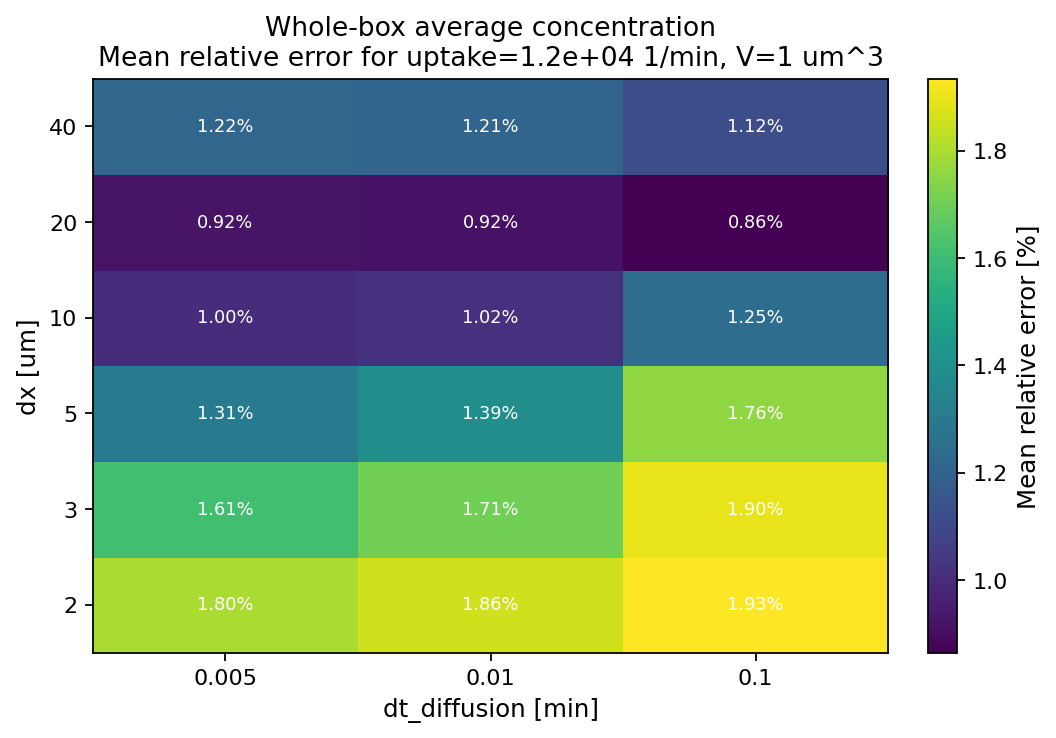

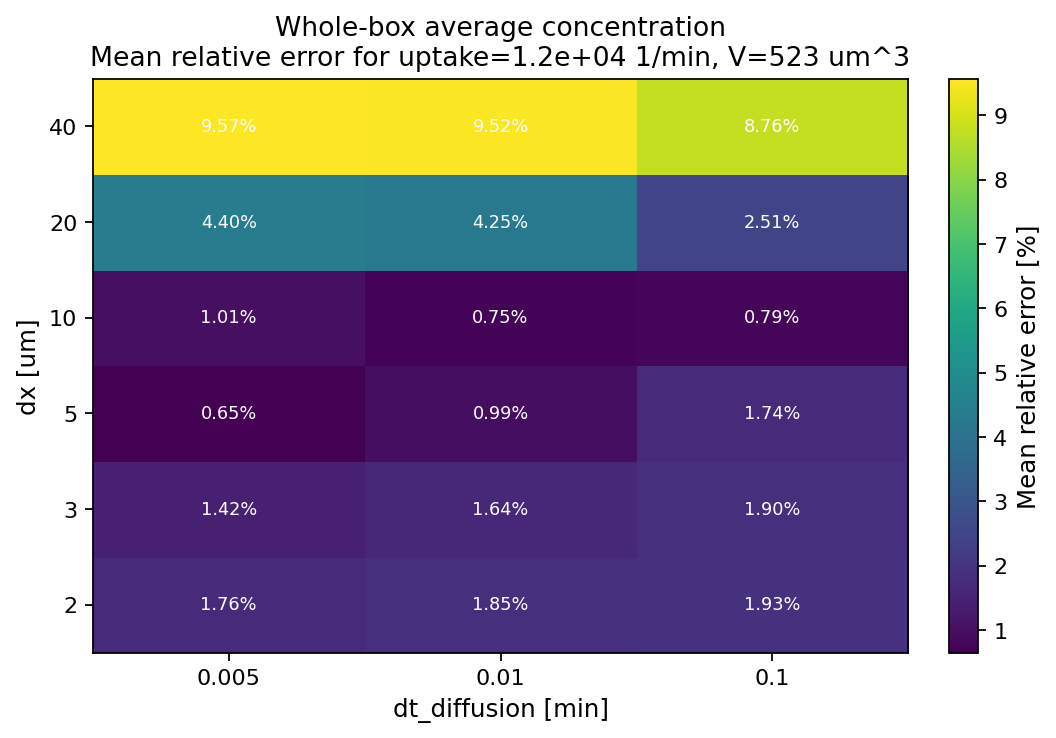

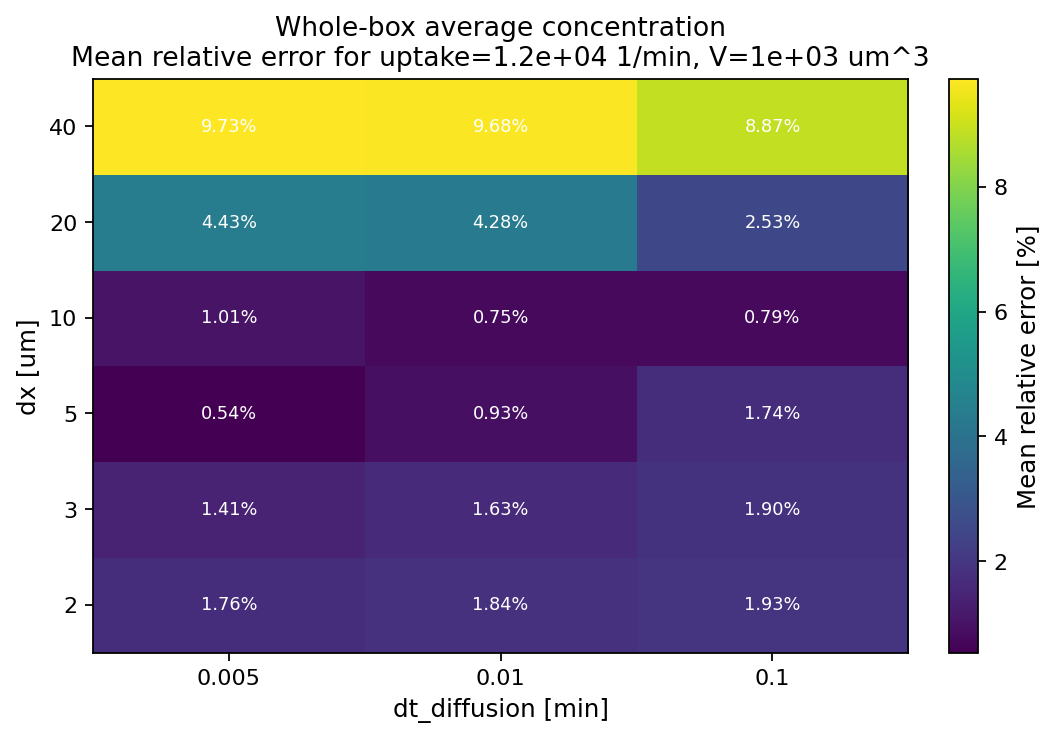

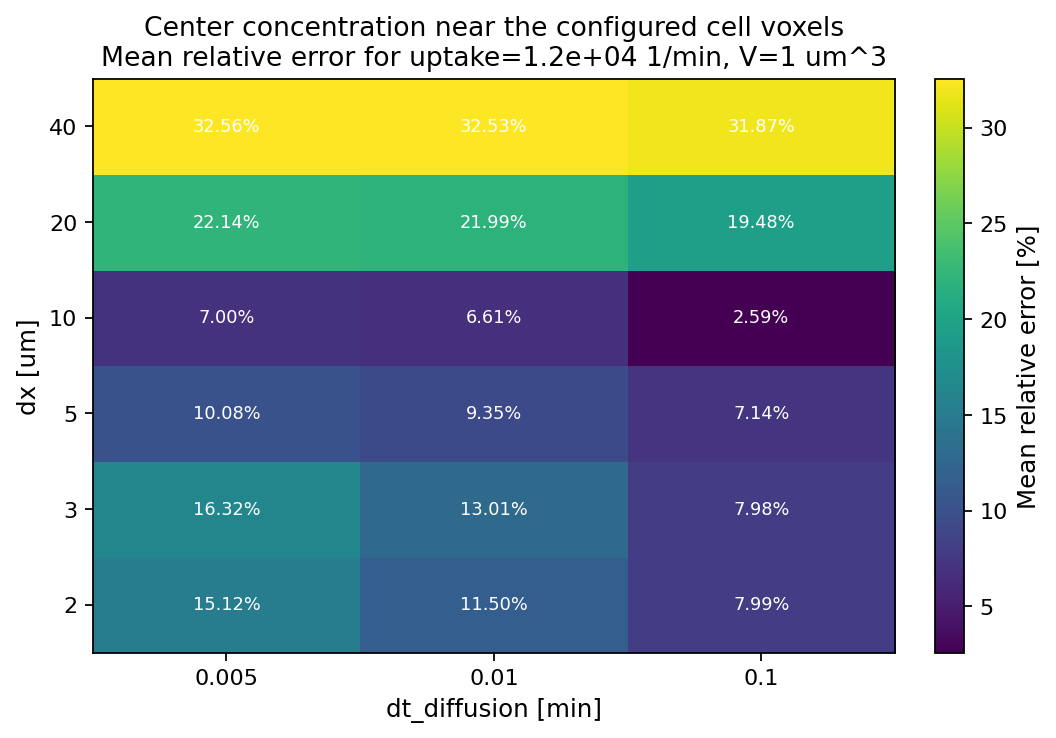

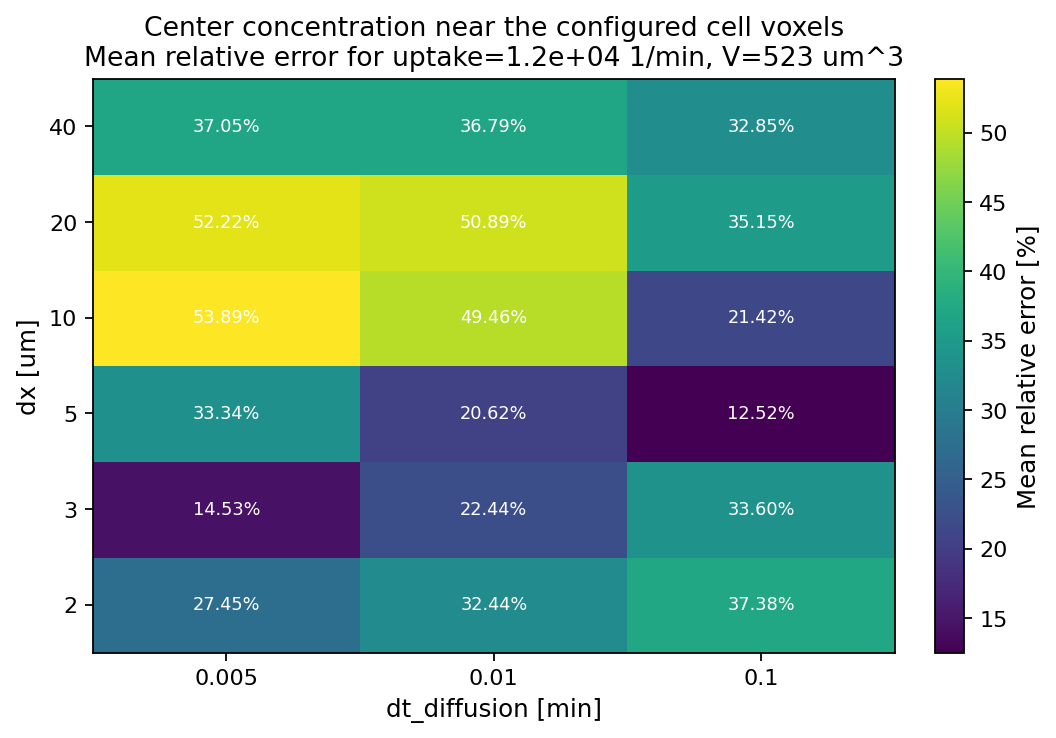

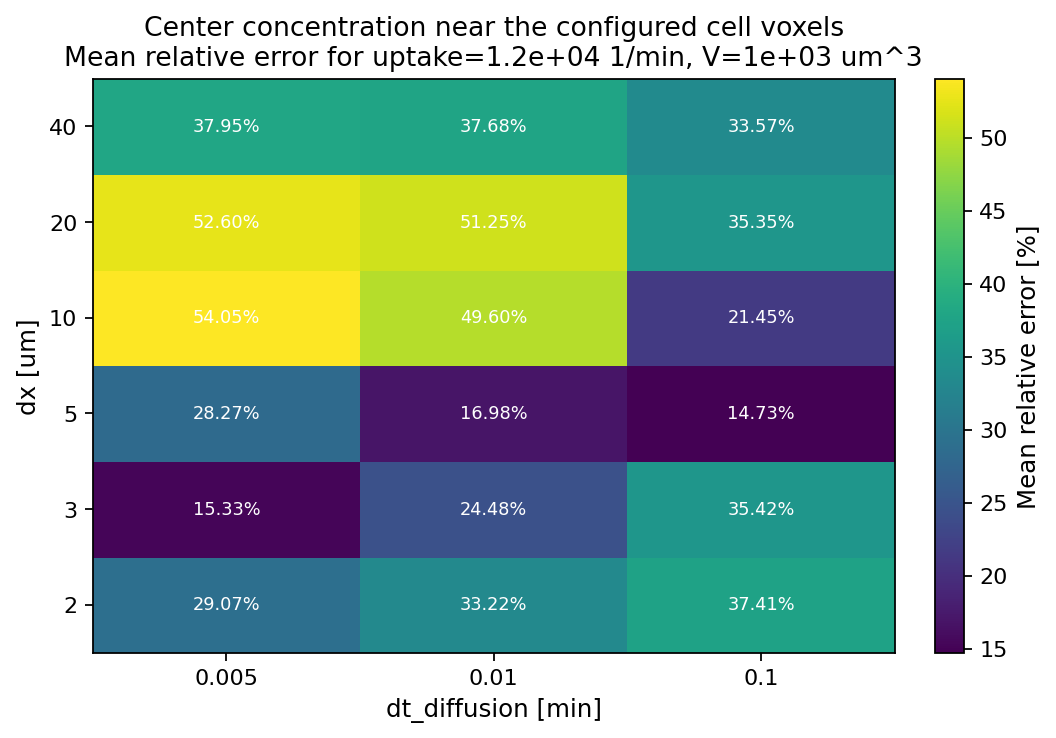

In [32]:
metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration near the configured cell voxels',
}

display(run_metrics)

for metric_name in ['average', 'center']:
    metric_metrics = run_metrics[run_metrics['metric'] == metric_name].copy()

    for uptake_rate in sorted(metric_metrics['uptake_rate_per_min'].unique()):
        for total_volume_um3 in sorted(metric_metrics['total_volume_um3'].unique()):
            subset = metric_metrics[
                (metric_metrics['uptake_rate_per_min'] == uptake_rate)
                & (metric_metrics['total_volume_um3'] == total_volume_um3)
            ].copy()
            heatmap = subset.pivot(index='dx_um', columns='dt_diffusion_min', values='mean_relative_error_percent')

            fig, axis = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
            image = axis.imshow(heatmap.values, aspect='auto', origin='lower', cmap='viridis')
            axis.set_xticks(np.arange(len(heatmap.columns)))
            axis.set_xticklabels([f'{value:g}' for value in heatmap.columns])
            axis.set_yticks(np.arange(len(heatmap.index)))
            axis.set_yticklabels([f'{value:g}' for value in heatmap.index])
            axis.set_xlabel('dt_diffusion [min]')
            axis.set_ylabel('dx [um]')
            axis.set_title(
                f'{metric_titles[metric_name]}\nMean relative error for uptake={uptake_rate:.3g} 1/min, V={total_volume_um3:.3g} um^3'
            )

            for row_index in range(len(heatmap.index)):
                for col_index in range(len(heatmap.columns)):
                    axis.text(
                        col_index,
                        row_index,
                        f'{heatmap.values[row_index, col_index]:.2f}%',
                        ha='center',
                        va='center',
                        color='white',
                        fontsize=8,
                    )

            fig.colorbar(image, ax=axis, label='Mean relative error [%]')
            plt.show()

## Parameter Effect Analysis

These cells isolate which sweep variables change the error most strongly.

They add three views:
- main-effects plots averaged over the other parameters
- interaction plots for `dx_um` versus `dt_diffusion_min`, faceted by total volume
- a standardized sensitivity ranking based on a log-log linear model

If a variable has only one value in the sweep, the cells skip that variable automatically.

In [27]:
PARAM_COLUMNS = ['dx_um', 'dt_diffusion_min', 'uptake_rate_per_min', 'total_volume_um3']
RUN_METRICS_CSV = SWEEP_ROOT / 'physicell_vs_analytical_run_metrics.csv'
TIMESERIES_CSV = SWEEP_ROOT / 'physicell_vs_analytical_timeseries.csv'

if 'run_metrics' not in globals():
    run_metrics = pd.read_csv(RUN_METRICS_CSV)
if 'comparison_long' not in globals():
    comparison_long = pd.read_csv(TIMESERIES_CSV)

variable_levels = {column: sorted(run_metrics[column].dropna().unique()) for column in PARAM_COLUMNS}
varying_parameters = [column for column, values in variable_levels.items() if len(values) > 1]

print('Varying parameters:', varying_parameters if varying_parameters else 'None')
for column in PARAM_COLUMNS:
    print(f"{column}: {variable_levels[column]}")

main_effect_rows = []
for metric_name, metric_frame in run_metrics.groupby('metric'):
    for parameter in varying_parameters:
        grouped = (
            metric_frame.groupby(parameter, as_index=False)
            .agg(
                mean_relative_error_percent=('mean_relative_error_percent', 'mean'),
                min_relative_error_percent=('mean_relative_error_percent', 'min'),
                max_relative_error_percent=('mean_relative_error_percent', 'max'),
                mean_absolute_error_uM=('mean_absolute_error_uM', 'mean'),
                run_count=('run_id', 'size'),
            )
            .sort_values(parameter)
            .reset_index(drop=True)
        )
        grouped.insert(0, 'parameter', parameter)
        grouped.insert(0, 'metric', metric_name)
        main_effect_rows.append(grouped)

main_effects = pd.concat(main_effect_rows, ignore_index=True) if main_effect_rows else pd.DataFrame()

effect_strength = []
for metric_name, metric_frame in run_metrics.groupby('metric'):
    for parameter in varying_parameters:
        parameter_means = metric_frame.groupby(parameter)['mean_relative_error_percent'].mean()
        effect_strength.append({
            'metric': metric_name,
            'parameter': parameter,
            'effect_span_percent': float(parameter_means.max() - parameter_means.min()),
            'effect_ratio': float(parameter_means.max() / parameter_means.min()) if parameter_means.min() > 0 else np.nan,
        })

effect_strength = pd.DataFrame(effect_strength).sort_values(['metric', 'effect_span_percent'], ascending=[True, False]).reset_index(drop=True)
display(effect_strength)

Varying parameters: ['dx_um', 'dt_diffusion_min', 'total_volume_um3']
dx_um: [np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(40.0)]
dt_diffusion_min: [np.float64(0.005), np.float64(0.01), np.float64(0.1)]
uptake_rate_per_min: [np.int64(12044)]
total_volume_um3: [np.float64(1.0), np.float64(523.0), np.float64(1000.0)]


,metric,parameter,effect_span_percent,effect_ratio
0,average,dx_um,5.702309,7.139763
1,average,total_volume_um3,1.721546,2.250838
2,average,dt_diffusion_min,0.111642,1.045467
3,center,dx_um,20.893323,2.228784
4,center,total_volume_um3,18.508840,2.210360
5,center,dt_diffusion_min,6.170833,1.259589


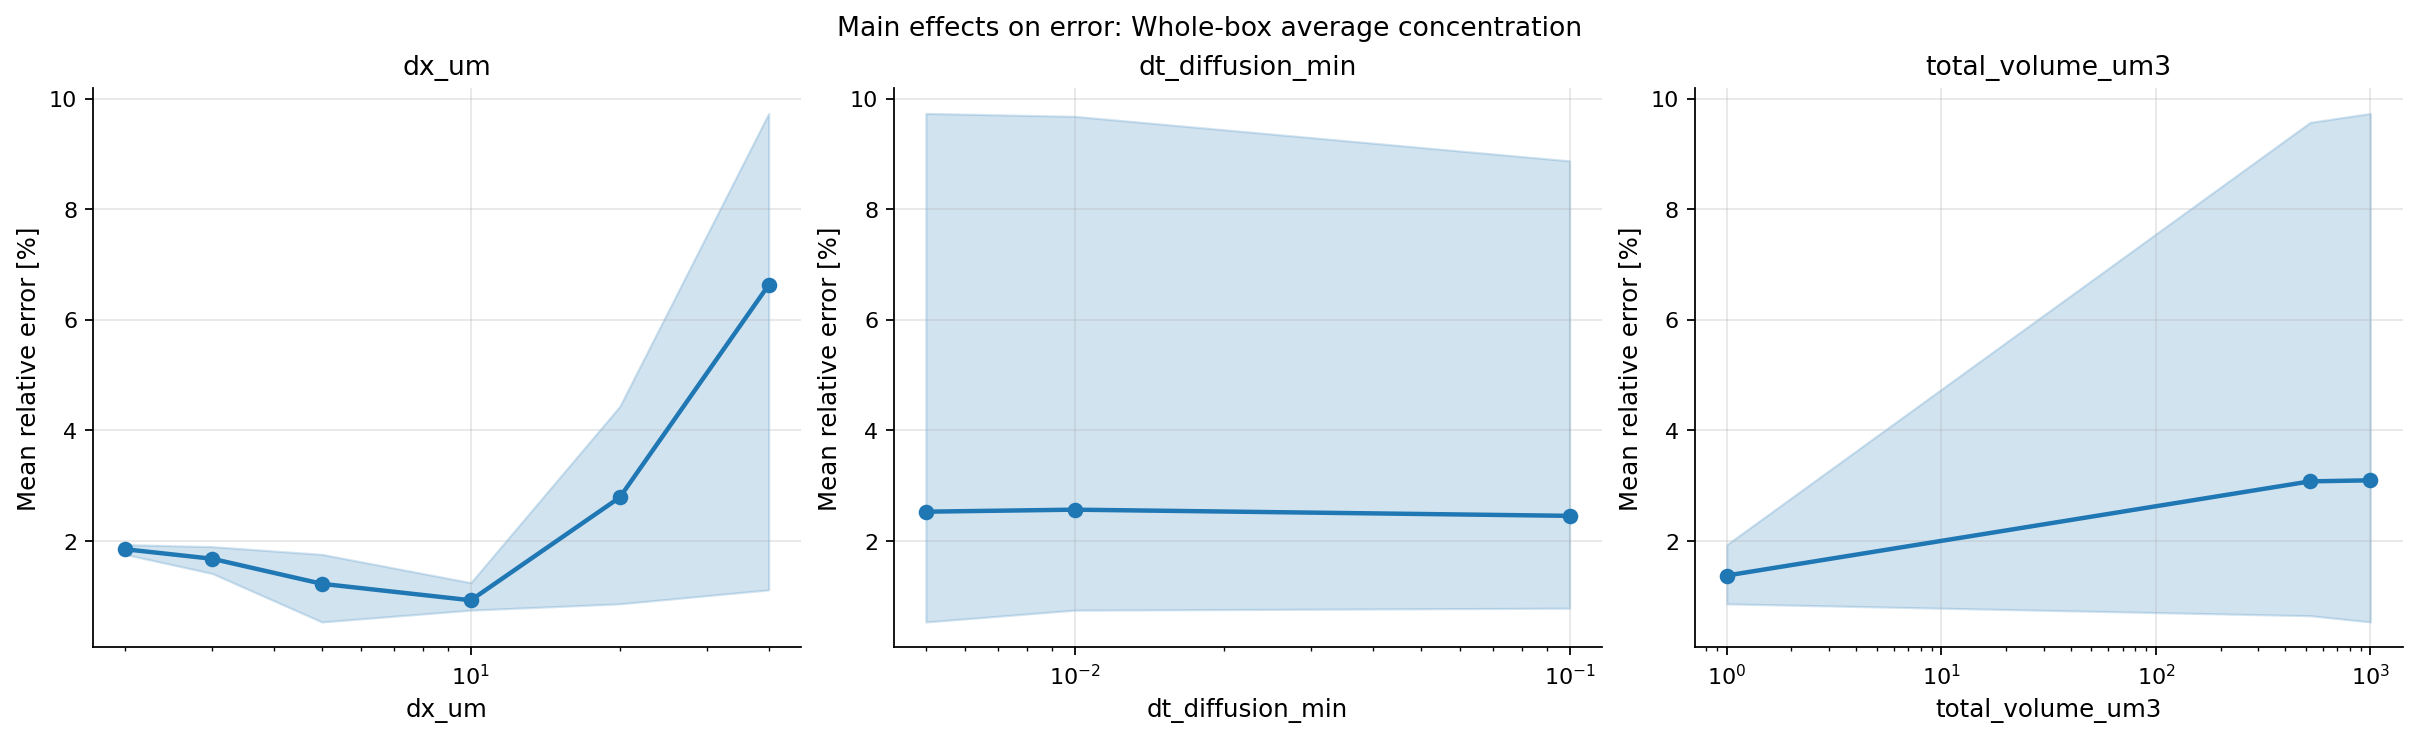

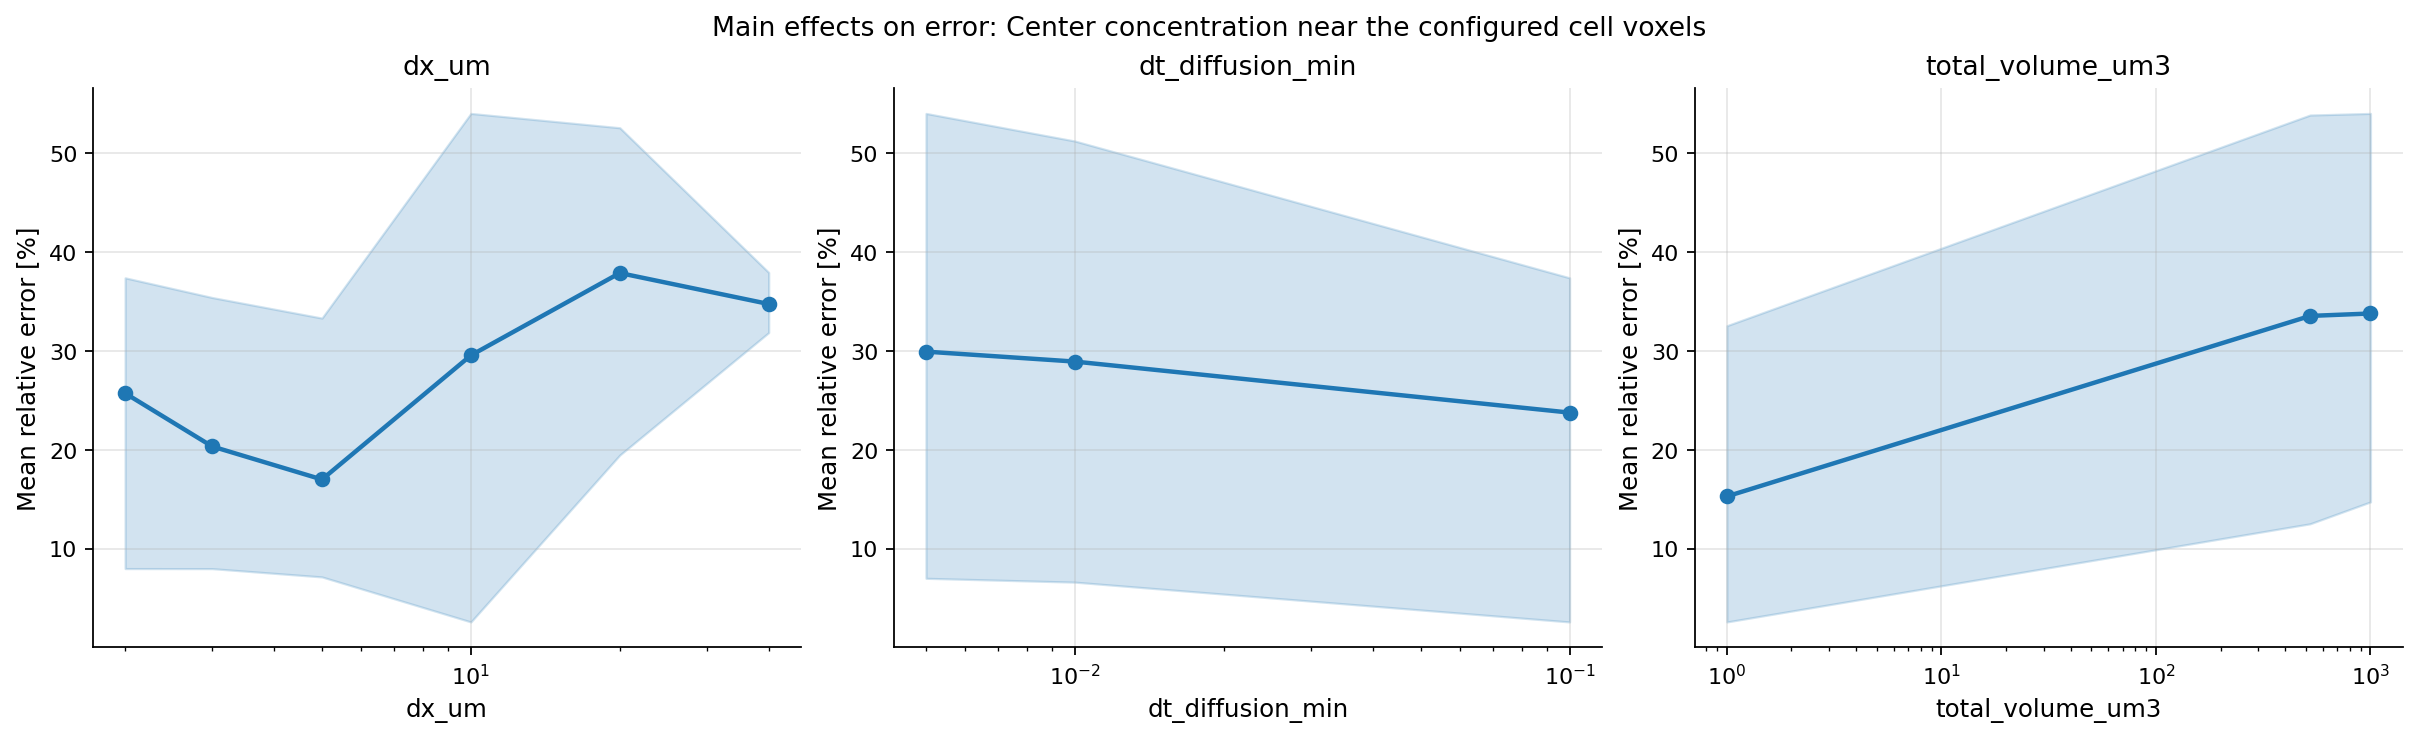

,metric,parameter,effect_span_percent,effect_ratio
0,average,dx_um,5.702309,7.139763
1,average,total_volume_um3,1.721546,2.250838
2,average,dt_diffusion_min,0.111642,1.045467
3,center,dx_um,20.893323,2.228784
4,center,total_volume_um3,18.508840,2.210360
5,center,dt_diffusion_min,6.170833,1.259589


In [28]:
metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration near the configured cell voxels',
}

if main_effects.empty:
    raise ValueError('No varying parameters are available for a main-effects plot.')

for metric_name in sorted(main_effects['metric'].unique()):
    metric_effects = main_effects[main_effects['metric'] == metric_name].copy()
    parameter_count = len(varying_parameters)
    fig, axes = plt.subplots(1, parameter_count, figsize=(5.0 * parameter_count, 4.5), constrained_layout=True)
    if parameter_count == 1:
        axes = [axes]

    for axis, parameter in zip(axes, varying_parameters):
        subset = metric_effects[metric_effects['parameter'] == parameter].sort_values(parameter)
        x_values = subset[parameter].to_numpy(dtype=float)
        mean_values = subset['mean_relative_error_percent'].to_numpy(dtype=float)
        min_values = subset['min_relative_error_percent'].to_numpy(dtype=float)
        max_values = subset['max_relative_error_percent'].to_numpy(dtype=float)

        axis.plot(x_values, mean_values, marker='o', linewidth=2.0, color='tab:blue')
        axis.fill_between(x_values, min_values, max_values, alpha=0.2, color='tab:blue')
        axis.set_xlabel(parameter)
        axis.set_ylabel('Mean relative error [%]')
        axis.set_title(parameter)
        style_axis(axis)
        if np.all(x_values > 0) and parameter in {'dx_um', 'dt_diffusion_min', 'uptake_rate_per_min', 'total_volume_um3'}:
            axis.set_xscale('log')

    fig.suptitle(f"Main effects on error: {metric_titles[metric_name]}")
    plt.show()

display(effect_strength)

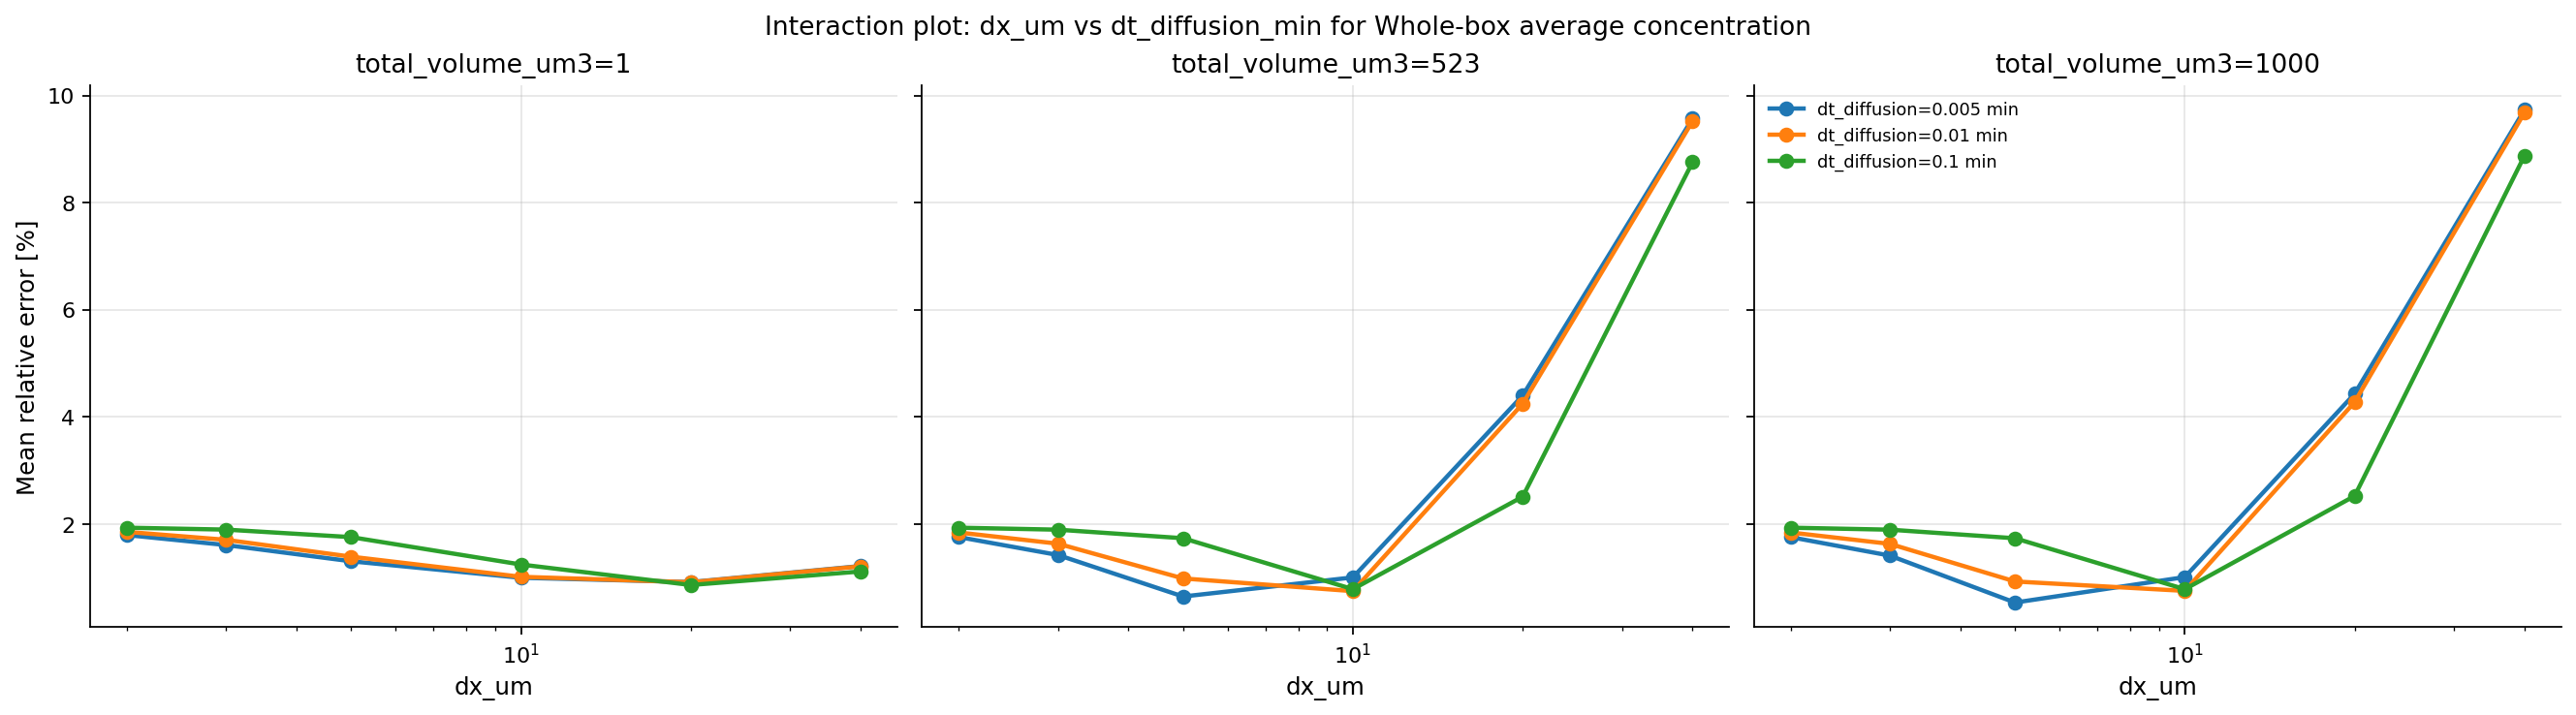

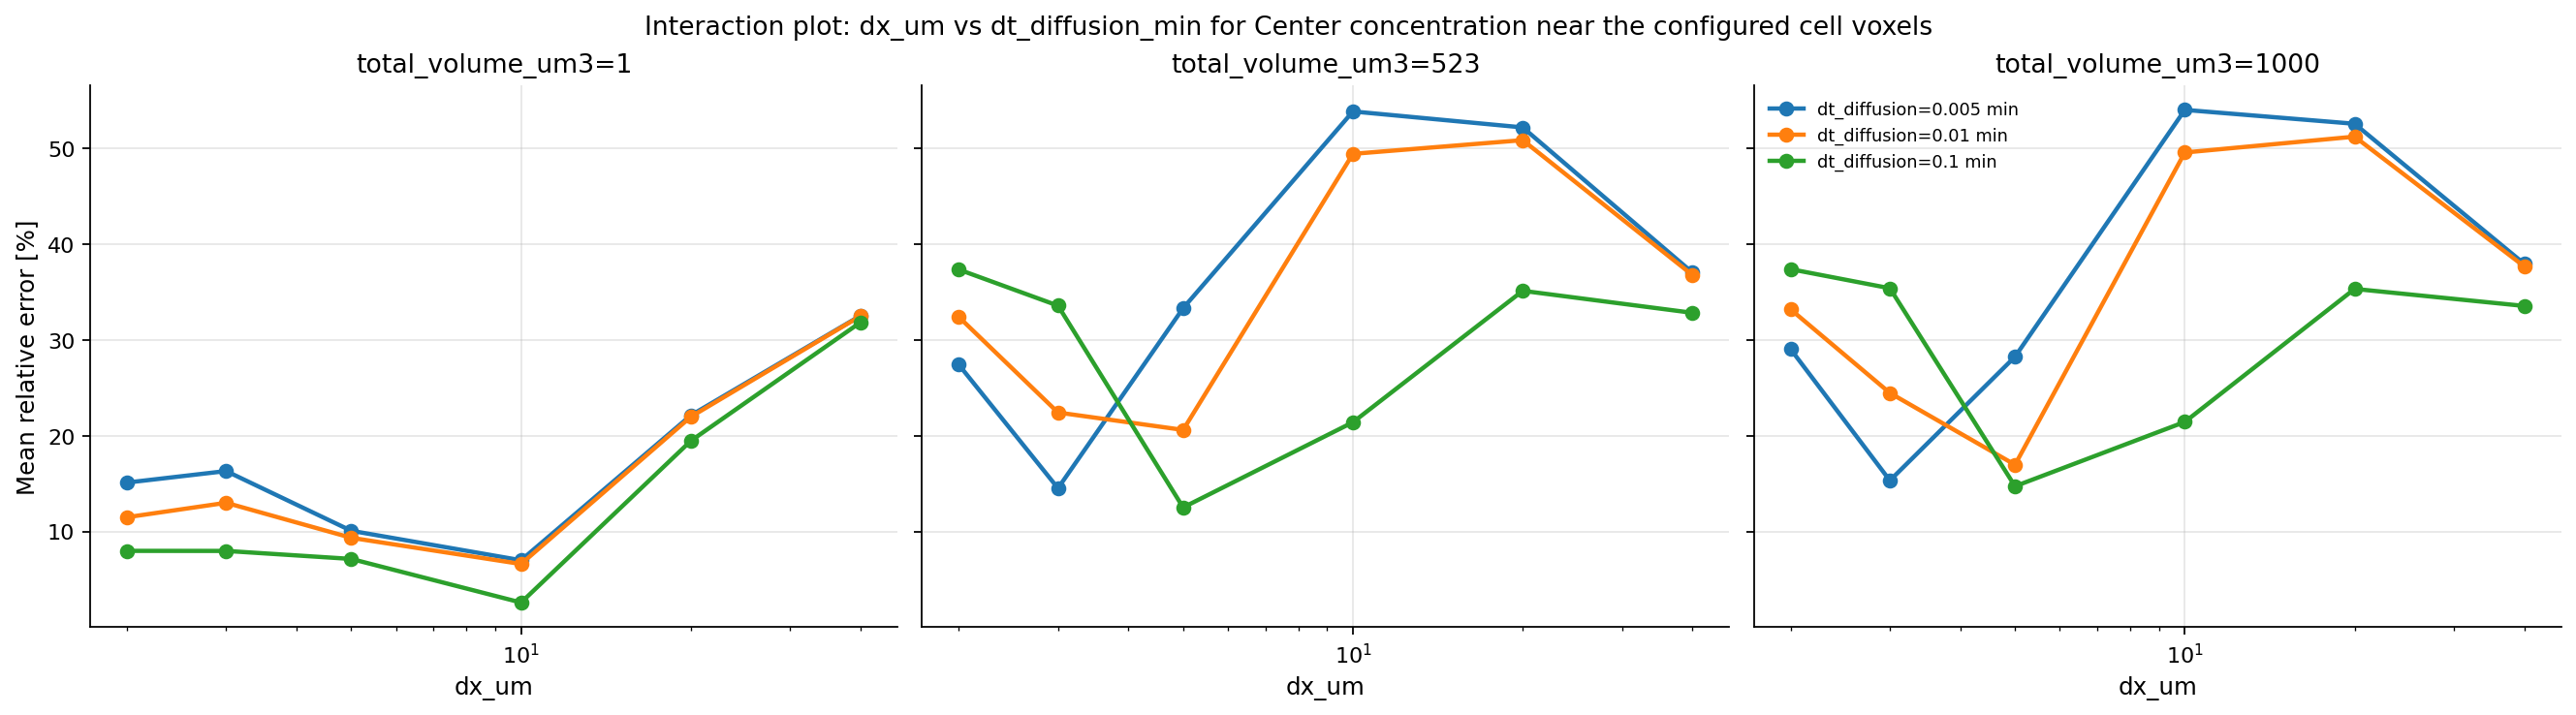

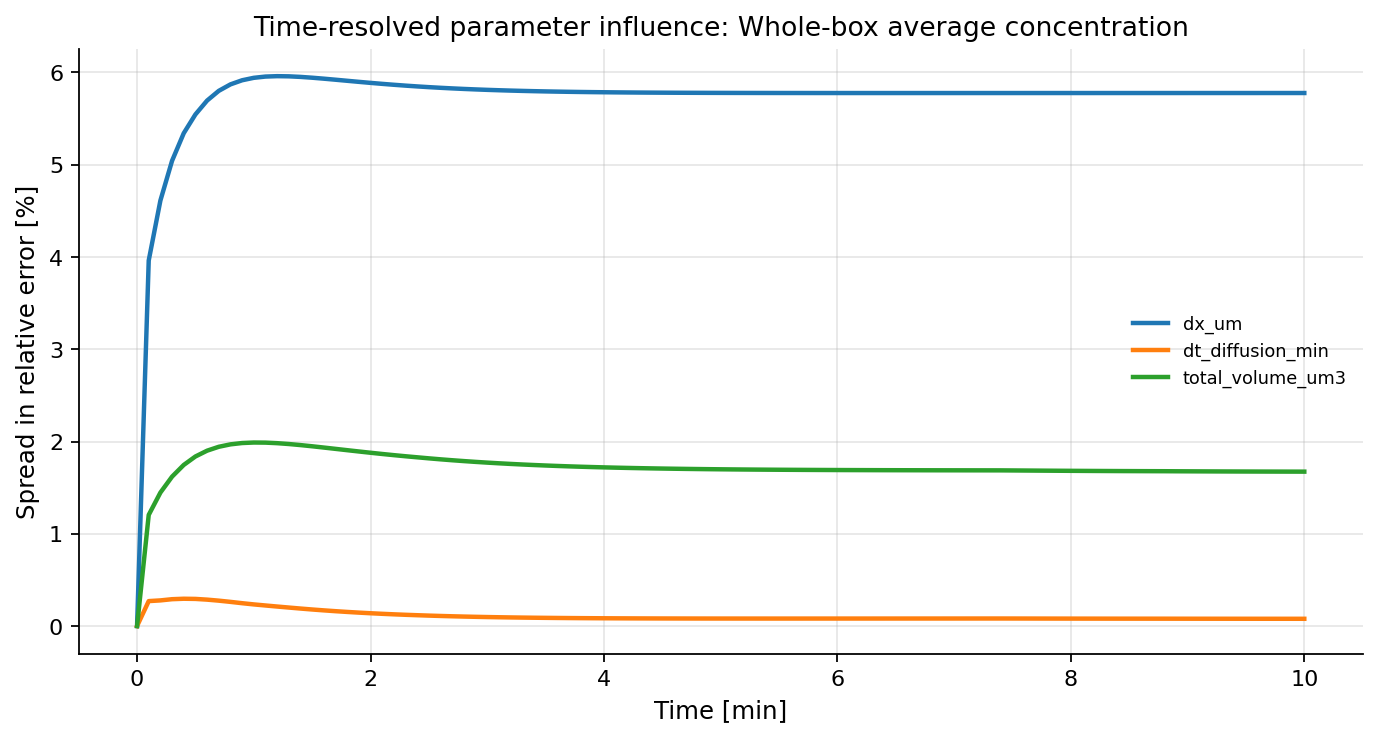

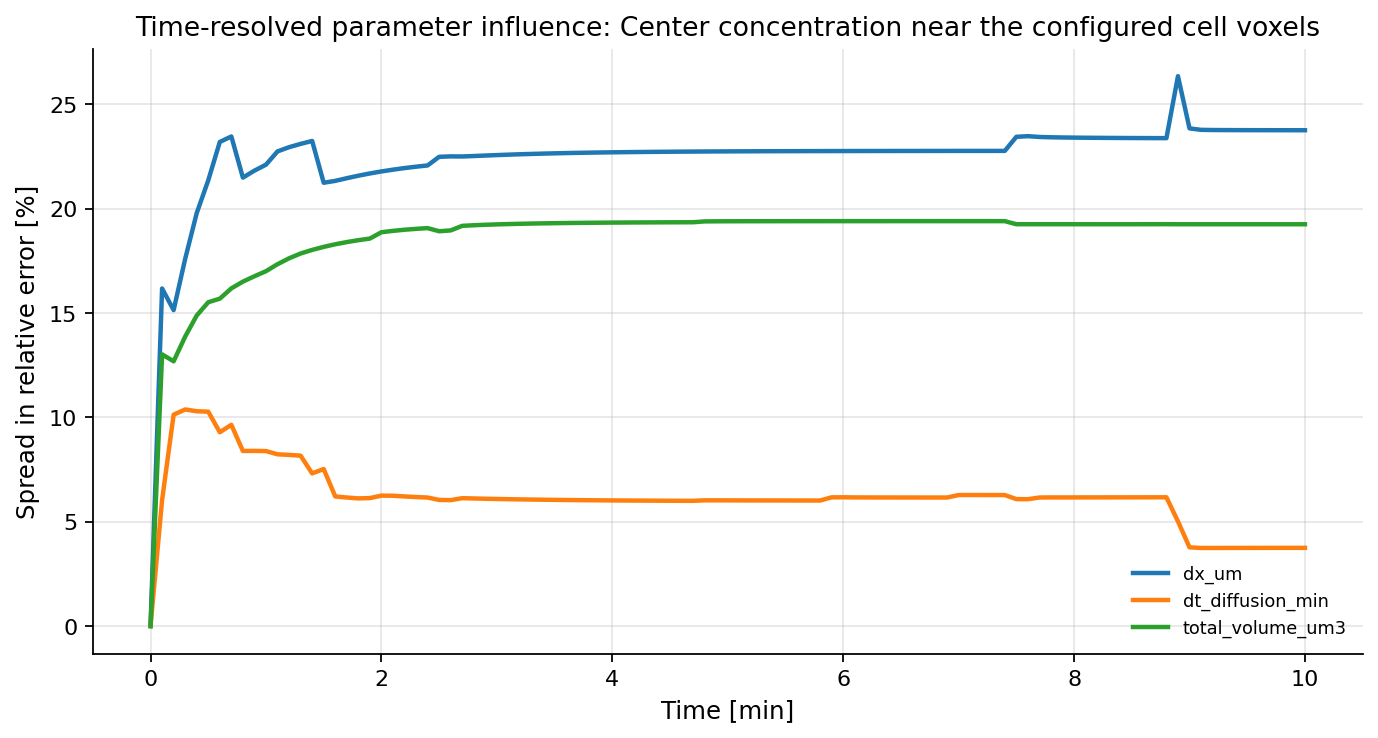

In [30]:
interaction_columns = {'x': 'dx_um', 'line': 'dt_diffusion_min', 'facet': 'total_volume_um3'}

required_columns = list(interaction_columns.values())
if not all(column in varying_parameters or len(variable_levels[column]) == 1 for column in required_columns):
    raise ValueError('The interaction plot requires dx_um, dt_diffusion_min, and total_volume_um3 columns.')

for metric_name in sorted(run_metrics['metric'].unique()):
    metric_frame = run_metrics[run_metrics['metric'] == metric_name].copy()
    facet_values = sorted(metric_frame[interaction_columns['facet']].dropna().unique())
    fig, axes = plt.subplots(1, len(facet_values), figsize=(5.5 * len(facet_values), 4.5), sharey=True, constrained_layout=True)
    if len(facet_values) == 1:
        axes = [axes]

    for axis, facet_value in zip(axes, facet_values):
        subset = metric_frame[metric_frame[interaction_columns['facet']] == facet_value].copy()
        line_values = sorted(subset[interaction_columns['line']].dropna().unique())

        for line_value in line_values:
            line_subset = subset[subset[interaction_columns['line']] == line_value].copy()
            line_subset = line_subset.groupby(interaction_columns['x'], as_index=False)['mean_relative_error_percent'].mean()
            line_subset = line_subset.sort_values(interaction_columns['x'])
            axis.plot(
                line_subset[interaction_columns['x']],
                line_subset['mean_relative_error_percent'],
                marker='o',
                linewidth=2.0,
                label=f"dt_diffusion={line_value:g} min",
            )

        axis.set_xscale('log')
        axis.set_xlabel('dx_um')
        axis.set_title(f"total_volume_um3={facet_value:g}")
        style_axis(axis)

    axes[0].set_ylabel('Mean relative error [%]')
    axes[-1].legend(frameon=False, loc='best')
    fig.suptitle(f"Interaction plot: dx_um vs dt_diffusion_min for {metric_titles[metric_name]}")
    plt.show()

time_effect_rows = []
for metric_name, metric_frame in comparison_long.groupby('metric'):
    for parameter in varying_parameters:
        grouped = (
            metric_frame.groupby(['time_min', parameter], as_index=False)['relative_error_percent']
            .mean()
        )
        spread = (
            grouped.groupby('time_min', as_index=False)
            .agg(
                min_relative_error_percent=('relative_error_percent', 'min'),
                max_relative_error_percent=('relative_error_percent', 'max'),
            )
        )
        spread['spread_relative_error_percent'] = spread['max_relative_error_percent'] - spread['min_relative_error_percent']
        spread['metric'] = metric_name
        spread['parameter'] = parameter
        time_effect_rows.append(spread)

time_effects = pd.concat(time_effect_rows, ignore_index=True) if time_effect_rows else pd.DataFrame()

for metric_name in sorted(time_effects['metric'].unique()):
    metric_time_effects = time_effects[time_effects['metric'] == metric_name].copy()
    fig, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
    for parameter in varying_parameters:
        subset = metric_time_effects[metric_time_effects['parameter'] == parameter].sort_values('time_min')
        axis.plot(
            subset['time_min'],
            subset['spread_relative_error_percent'],
            linewidth=2.0,
            label=parameter,
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Spread in relative error [%]')
    axis.set_title(f"Time-resolved parameter influence: {metric_titles[metric_name]}")
    style_axis(axis)
    axis.legend(frameon=False)
    plt.show()

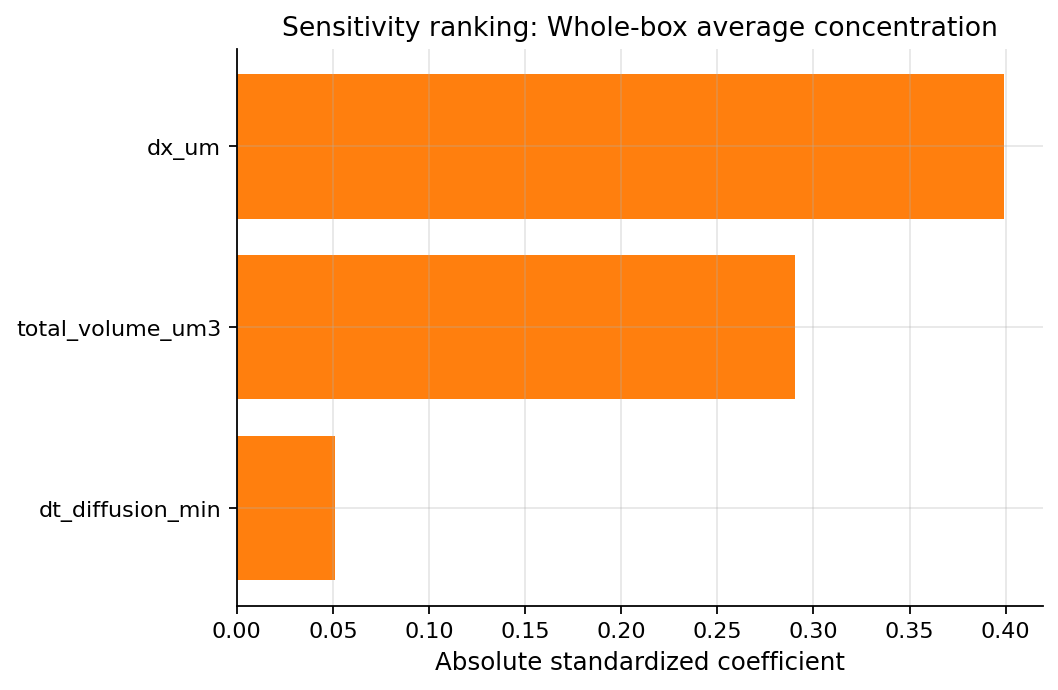

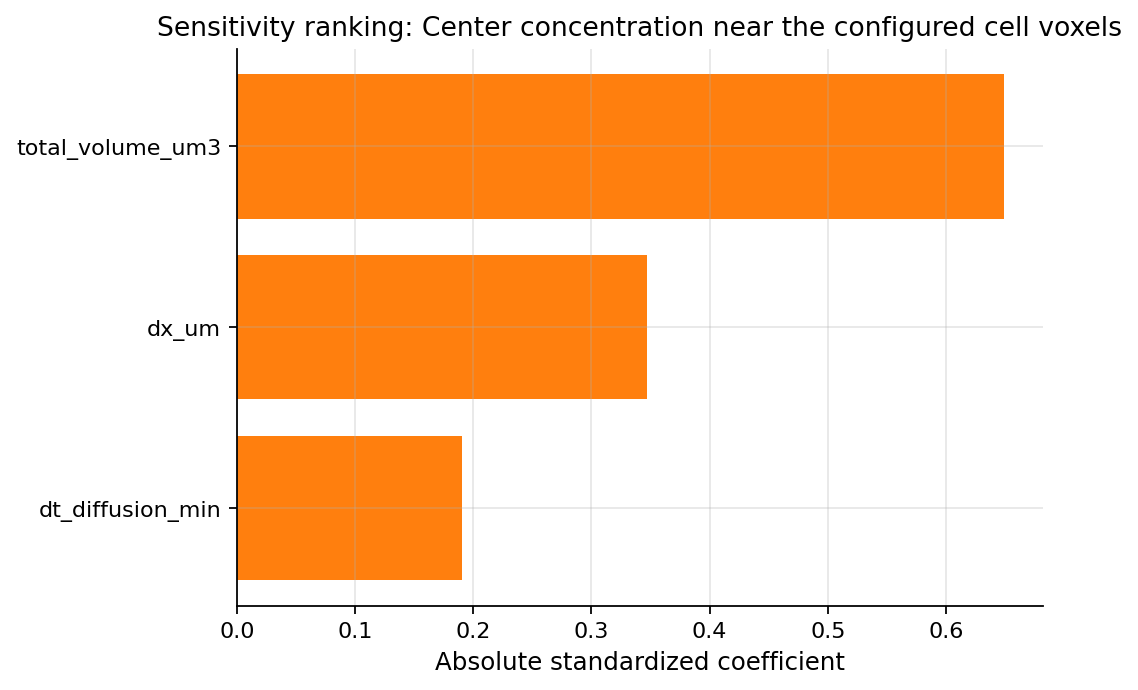

,parameter,coefficient,abs_coefficient,metric
0,dx_um,0.399296,0.399296,average
1,total_volume_um3,0.290177,0.290177,average
2,dt_diffusion_min,0.050962,0.050962,average
3,total_volume_um3,0.649310,0.649310,center
4,dx_um,0.347319,0.347319,center
5,dt_diffusion_min,-0.190293,0.190293,center


In [31]:
def standardized_linear_coefficients(frame: pd.DataFrame, response_column: str, candidate_columns: list[str]) -> pd.DataFrame:
    working = frame.copy()
    usable_columns = []
    for column in candidate_columns:
        unique_values = working[column].dropna().unique()
        if len(unique_values) > 1 and (working[column] > 0).all():
            usable_columns.append(column)

    if not usable_columns:
        return pd.DataFrame(columns=['parameter', 'coefficient', 'abs_coefficient'])

    transformed = pd.DataFrame({column: np.log10(working[column].astype(float)) for column in usable_columns})
    response = np.log10(working[response_column].astype(float).clip(lower=1e-12))

    x_scaled = (transformed - transformed.mean()) / transformed.std(ddof=0)
    y_scaled = (response - response.mean()) / response.std(ddof=0)

    design_matrix = np.column_stack([np.ones(len(x_scaled)), x_scaled.to_numpy(dtype=float)])
    coefficients, _, _, _ = np.linalg.lstsq(design_matrix, y_scaled.to_numpy(dtype=float), rcond=None)

    result = pd.DataFrame({
        'parameter': usable_columns,
        'coefficient': coefficients[1:],
    })
    result['abs_coefficient'] = result['coefficient'].abs()
    return result.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

sensitivity_tables = []
for metric_name in sorted(run_metrics['metric'].unique()):
    metric_frame = run_metrics[run_metrics['metric'] == metric_name].copy()
    sensitivity = standardized_linear_coefficients(
        metric_frame,
        response_column='mean_relative_error_percent',
        candidate_columns=PARAM_COLUMNS,
    )
    sensitivity['metric'] = metric_name
    sensitivity_tables.append(sensitivity)

    fig, axis = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
    axis.barh(sensitivity['parameter'], sensitivity['abs_coefficient'], color='tab:orange')
    axis.invert_yaxis()
    axis.set_xlabel('Absolute standardized coefficient')
    axis.set_title(f"Sensitivity ranking: {metric_titles[metric_name]}")
    style_axis(axis)
    plt.show()

sensitivity_summary = pd.concat(sensitivity_tables, ignore_index=True) if sensitivity_tables else pd.DataFrame()
display(sensitivity_summary)

## Origin Interpolation Reference

This section computes the center concentration at the box origin by interpolating the eight surrounding voxels instead of taking the nearest voxel. That avoids the grid-alignment artifact that appears when the origin sits between voxel centers.

,run_id,dx_um,dt_diffusion_min,total_volume_um3,mean_origin_absolute_error_uM,mean_origin_relative_error_percent
1,dx_10um__uptake_12044__dtdiff_0p005min__volume...,10.0,0.005,1.0,0.077201,0.996119
4,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,10.0,0.010,1.0,0.105710,1.382119
7,dx_10um__uptake_12044__dtdiff_0p1min__volume_1um3,10.0,0.100,1.0,0.819010,11.219572
16,dx_20um__uptake_12044__dtdiff_0p1min__volume_1um3,20.0,0.100,1.0,0.985064,13.648174
27,dx_3um__uptake_12044__dtdiff_0p005min__volume_...,3.0,0.005,1000.0,1.241731,16.842762
13,dx_20um__uptake_12044__dtdiff_0p01min__volume_...,20.0,0.010,1.0,1.269457,17.583466
10,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,0.005,1.0,1.286812,17.823550
29,dx_3um__uptake_12044__dtdiff_0p005min__volume_...,3.0,0.005,523.0,1.395749,18.829899
46,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,0.005,1.0,1.581321,21.721964
49,dx_5um__uptake_12044__dtdiff_0p01min__volume_1um3,5.0,0.010,1.0,1.624555,22.314810


/home/tntiniak/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


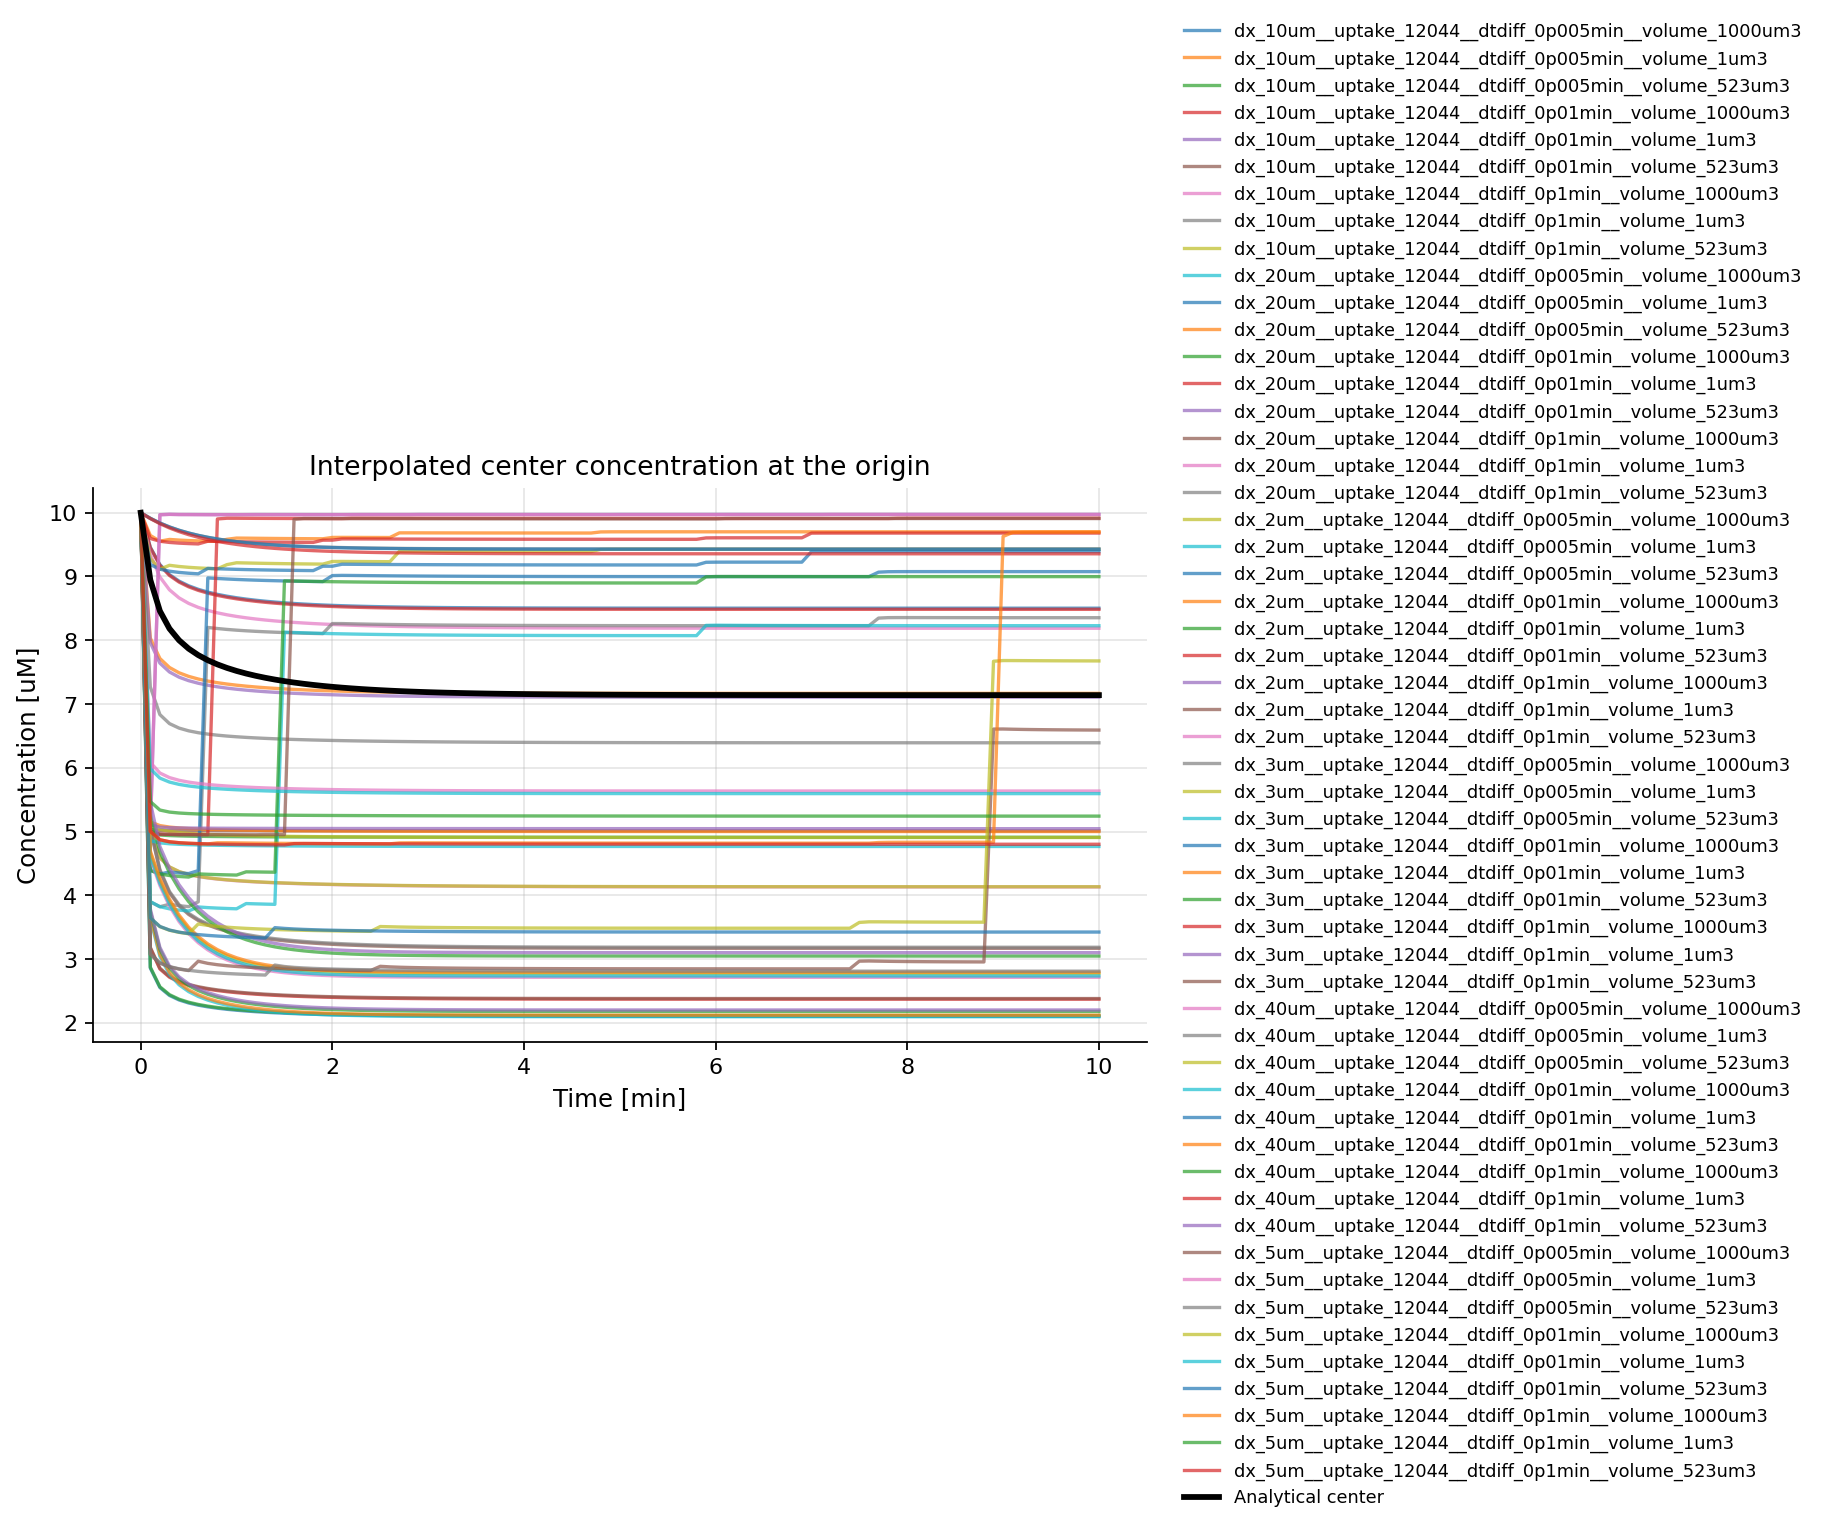

In [33]:
def trilinear_interpolate_origin(microenvironment: np.ndarray) -> float:
    x_axis = np.unique(microenvironment[0])
    y_axis = np.unique(microenvironment[1])
    z_axis = np.unique(microenvironment[2])
    concentration_field = microenvironment[4]

    def bracketing_indices(axis_values: np.ndarray) -> tuple[int, int]:
        right = int(np.searchsorted(axis_values, 0.0, side='left'))
        if right <= 0:
            right = 1
        if right >= len(axis_values):
            right = len(axis_values) - 1
        left = right - 1
        return left, right

    x0, x1 = bracketing_indices(x_axis)
    y0, y1 = bracketing_indices(y_axis)
    z0, z1 = bracketing_indices(z_axis)

    x_lo, x_hi = float(x_axis[x0]), float(x_axis[x1])
    y_lo, y_hi = float(y_axis[y0]), float(y_axis[y1])
    z_lo, z_hi = float(z_axis[z0]), float(z_axis[z1])

    def weight(value: float, low: float, high: float) -> float:
        if high == low:
            return 0.0
        return (value - low) / (high - low)

    wx = weight(0.0, x_lo, x_hi)
    wy = weight(0.0, y_lo, y_hi)
    wz = weight(0.0, z_lo, z_hi)

    dims = (len(x_axis), len(y_axis), len(z_axis))
    values = {}
    for ix in [x0, x1]:
        for iy in [y0, y1]:
            for iz in [z0, z1]:
                flat_index = np.ravel_multi_index((ix, iy, iz), dims)
                values[(ix, iy, iz)] = concentration_field[flat_index] / 602.2

    interpolated = 0.0
    for ix, x_weight in [(x0, 1.0 - wx), (x1, wx)]:
        for iy, y_weight in [(y0, 1.0 - wy), (y1, wy)]:
            for iz, z_weight in [(z0, 1.0 - wz), (z1, wz)]:
                interpolated += x_weight * y_weight * z_weight * values[(ix, iy, iz)]

    return interpolated

origin_center_rows = []
for run_id, run_frame in all_runs.groupby('run_id'):
    folder = run_directories[run_summary.index[run_summary['run_id'] == run_id][0]]
    reader = multicellds.MultiCellDS(output_folder=str(folder))
    origin_uM = []
    for _, microenvironment in reader.microenvironment_as_matrix_iterator():
        origin_uM.append(trilinear_interpolate_origin(microenvironment))

    origin_center_rows.append(pd.DataFrame({
        'run_id': run_id,
        'time_min': run_frame['time_min'].to_numpy(dtype=float),
        'origin_center_uM': np.array(origin_uM, dtype=float),
    }))

origin_center_df = pd.concat(origin_center_rows, ignore_index=True)
origin_comparison = comparison.merge(origin_center_df, on=['run_id', 'time_min'], how='inner', validate='one_to_one')
origin_comparison['origin_absolute_error_uM'] = (origin_comparison['origin_center_uM'] - origin_comparison['center_concentration_uM']).abs()
origin_comparison['origin_relative_error_percent'] = 100.0 * origin_comparison['origin_absolute_error_uM'] / origin_comparison['center_concentration_uM'].abs()

origin_run_summary = (
    origin_comparison.groupby(['run_id', 'dx_um', 'dt_diffusion_min', 'total_volume_um3'], as_index=False)
    .agg(
        mean_origin_absolute_error_uM=('origin_absolute_error_uM', 'mean'),
        mean_origin_relative_error_percent=('origin_relative_error_percent', 'mean'),
    )
    .sort_values(['mean_origin_relative_error_percent', 'mean_origin_absolute_error_uM'])
)
display(origin_run_summary)

fig, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
for run_id, group in origin_comparison.groupby('run_id'):
    group = group.sort_values('time_min')
    axis.plot(group['time_min'], group['origin_center_uM'], alpha=0.7, linewidth=1.5, label=run_id)

axis.plot(analytical_df['time_min'], analytical_df['center_concentration_uM'], color='black', linewidth=2.6, label='Analytical center')
axis.set_xlabel('Time [min]')
axis.set_ylabel('Concentration [uM]')
axis.set_title('Interpolated center concentration at the origin')
style_axis(axis)
axis.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()